[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Roman-HLIS-Cosmology-PIT/slimfarmer/blob/main/doc/Flux_error_validation_colab.ipynb)

# Flux_error_validation
In this notebook, we will use idealized simulation to validate the flux_err calculation in slimfarmer and also point out a serious problem in the correlated noise scenario.

**Part 1** — White (uncorrelated) Gaussian noise: `flux_err` should match `sigma_MC`.

**Part 2** — Correlated noise from real Roman data: `flux_err` is underestimated relative to `sigma_MC` because the weight map assumes white noise.


In [1]:
!apt-get install -y swig zlib1g-dev libcfitsio-dev libcairo2-dev \
    libjpeg-dev libnetpbm10-dev netpbm
!pip install numpy scipy matplotlib astropy
!git clone https://github.com/dstndstn/astrometry.net.git /content/astrometry.net
%cd /content/astrometry.net
!make
!make py
!make extra
!make install INSTALL_DIR=/content/astrometry-install

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libcairo2-dev is already the newest version (1.16.0-5ubuntu2).
libjpeg-dev is already the newest version (8c-2ubuntu10).
libjpeg-dev set to manually installed.
libcfitsio-dev is already the newest version (4.0.0-1).
libcfitsio-dev set to manually installed.
zlib1g-dev is already the newest version (1:1.2.11.dfsg-2ubuntu9.2).
zlib1g-dev set to manually installed.
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript libgs9
  libgs9-common libidn12 libijs-0.35 libjbig2dec0 libnetpbm10 poppler-data
  swig4.0
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x poppler-utils fonts-japanese-mincho | fonts-ipafont-mincho
  fonts-japanese-gothic | fonts-ipafont-gothic fonts-arphic-ukai
  fonts-arphic-uming fonts-nanum swig-doc swig-examples swig4.0-examples
  swig4.0-doc
The followi

In [2]:
import sys, os
os.environ['PYTHONPATH'] = '/content/astrometry-install/lib/python'
sys.path.insert(0, '/content/astrometry-install/lib/python')

# Cell 5: Verify astrometry.util works
from astrometry.util.ttime import Time
print("astrometry.util OK!")

astrometry.util OK!


In [3]:
!git clone https://github.com/dstndstn/tractor.git
%cd tractor
!python setup.py build_ext --inplace --with-cython
!pip install .  --no-build-isolation

Cloning into 'tractor'...
remote: Enumerating objects: 16536, done.
remote: Counting objects: 100% (488/488), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 16536 (delta 434), reused 410 (delta 380), pack-reused 16048 (from 3)
Receiving objects: 100% (16536/16536), 43.35 MiB | 8.60 MiB/s, done.
Resolving deltas: 100% (12338/12338), done.
/content/astrometry.net/tractor
Compiling tractor/galaxy.py because it changed.
[1/1] Cythonizing tractor/galaxy.py
Compiling tractor/patch.pyx because it changed.
Compiling tractor/basics.py because it changed.
Compiling tractor/brightness.py because it changed.
Compiling tractor/ceres_optimizer.py because it changed.
Compiling tractor/cfht.py because it changed.
Compiling tractor/constrained_optimizer.py because it changed.
Compiling tractor/dense_optimizer.py because it changed.
Compiling tractor/ducks.py because it changed.
Compiling tractor/ellipses.py because it changed.
Compiling tractor/engine.py because it changed.
Comp

In [4]:
#Install all package
!pip install git+https://github.com/esheldon/fitsio.git#egg=fitsio
!pip install galsim
import tractor
print("Tractor imported successfully!")
!pip install git+https://github.com/Roman-HLIS-Cosmology-PIT/slimfarmer.git


  Cloning https://github.com/esheldon/fitsio.git to /tmp/pip-install-rolgxxaq/fitsio_9a96862109dd48bbbe04ddbd22a855ff
  Running command git clone --filter=blob:none --quiet https://github.com/esheldon/fitsio.git /tmp/pip-install-rolgxxaq/fitsio_9a96862109dd48bbbe04ddbd22a855ff
  Resolved https://github.com/esheldon/fitsio.git to commit c6a6b9f0e64ac4e497ca097c7323e119da38d784
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fitsio: filename=fitsio-1.3.1.dev32+gc6a6b9f0e-cp312-cp312-linux_x86_64.whl size=792916 sha256=74279b2304d64326fb1e5402b44fbdfa8528c6056bef2227e70cfada4a5f6bfb
  Stored in directory: /tmp/pip-ephem-wheel-cache-yqop_5q0/wheels/0c/7f/c3/b8e78a4aaf649c378387c9d3e925394920a1826b1d3e9be124
Successfully built fitsio
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.2/310.2 kB 22.7 MB/s eta 0:

In [27]:
%cd /content
!git clone https://github.com/Roman-HLIS-Cosmology-PIT/pyimcom.git
%cd /content/pyimcom
# Install dependencies then the package
!pip install -r requirements.txt
!pip install .

/content
Cloning into 'pyimcom'...
remote: Enumerating objects: 3089, done.
remote: Counting objects: 100% (1164/1164), done.
remote: Compressing objects: 100% (386/386), done.
remote: Total 3089 (delta 924), reused 794 (delta 760), pack-reused 1925 (from 2)
Receiving objects: 100% (3089/3089), 120.25 MiB | 20.21 MiB/s, done.
Resolving deltas: 100% (1953/1953), done.
/content/pyimcom
  Cloning https://github.com/Roman-HLIS-Cosmology-PIT/furry-parakeet (to revision main) to /tmp/pip-install-zcsvsvq6/furry-parakeet_6cec361f8f6d4ac5826359ad28ab2787
  Running command git clone --filter=blob:none --quiet https://github.com/Roman-HLIS-Cosmology-PIT/furry-parakeet /tmp/pip-install-zcsvsvq6/furry-parakeet_6cec361f8f6d4ac5826359ad28ab2787
  Resolved https://github.com/Roman-HLIS-Cosmology-PIT/furry-parakeet to commit 0cc10eed6bd991be4b554655e54fa46a9c5a6abb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Pr

Now I have download all the package.
Let's now download the necessary files

In [29]:
%cd /content

/content


In [34]:
!wget -O im3x2-H1_00_00.cpr.fits.gz "https://www.dropbox.com/scl/fo/m0p553ypvkpsdfd851sul/AJYJ9r0_pX0C37PWAqzOphE/H1_coadds_Grp0/im3x2-H1_00_00.cpr.fits.gz?rlkey=gsij7sy1zok89poz4wr3xzmia&st=aygyeyo3&dl=0"


--2026-03-30 02:28:09--  https://www.dropbox.com/scl/fo/m0p553ypvkpsdfd851sul/AJYJ9r0_pX0C37PWAqzOphE/H1_coadds_Grp0/im3x2-H1_00_00.cpr.fits.gz?rlkey=gsij7sy1zok89poz4wr3xzmia&st=aygyeyo3&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucb605aebc1761651a4190399c5e.dl.dropboxusercontent.com/cd/0/inline/C9mbgGwWiY7x0YKjHuRd-xjt0z36M_f_TX0IaNE_mLHnY98_vB2ZFZGhGRngm5b4iIdf0EQr5d0dhpvo-idC40_NFzctVSGT1L4XukI9_kkjcR5eAfLPiYQ5lN-Ln0VQIV76aXKVqGijd5-Aa7LKO18N/file# [following]
--2026-03-30 02:28:10--  https://ucb605aebc1761651a4190399c5e.dl.dropboxusercontent.com/cd/0/inline/C9mbgGwWiY7x0YKjHuRd-xjt0z36M_f_TX0IaNE_mLHnY98_vB2ZFZGhGRngm5b4iIdf0EQr5d0dhpvo-idC40_NFzctVSGT1L4XukI9_kkjcR5eAfLPiYQ5lN-Ln0VQIV76aXKVqGijd5-Aa7LKO18N/file
Resolving ucb605aebc1761651a4190399c5e.dl.dropboxusercontent.com (ucb605aeb

In [6]:
import sys, warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import galsim
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval, ImageNormalize
import slimfarmer
from scipy import stats
print(f'GalSim  {galsim.__version__}')
print(f'slimfarmer {slimfarmer.__version__}')


GalSim  2.8.4
slimfarmer 1.1.0


In [38]:
# First let's define some key parameters.
rng = galsim.BaseDeviate(42)
PIXEL_SCALE  = 0.049 # arcsec
STAMP_SIZE   = 125
PSF_FWHM     = 0.24 # arcsec
EXPTIME      = 107.0 *4

SKY_RATE     = 0.00
SKY_LEVEL    = SKY_RATE * EXPTIME
READ_NOISE   = 7.0
NOISE_SIGMA  = float(np.sqrt(SKY_LEVEL + READ_NOISE**2))
NOISE_SIGMA_RATE = NOISE_SIGMA / EXPTIME

ZP_RATE = 23.0
BAND    = 'F158'

SCI_PATH      = './galsim_sci.fits'
WHT_PATH      = './galsim_wht.fits'
EFF_GAIN_PATH = './galsim_eff_gain.fits'
PSF_PATH      = './galsim_psf.fits'
OUT_PATH      = './galsim_cat.fits'

print(f'EXPTIME          : {EXPTIME:.0f} s')
print(f'Zeropoint (rate) : {ZP_RATE} AB mag at 1 e-/s')
print(f'READ_NOISE       : {READ_NOISE:.0f} e/pix')
print(f'Noise floor      : {NOISE_SIGMA_RATE:.6f} e-/s/pix')


EXPTIME          : 428 s
Zeropoint (rate) : 23.0 AB mag at 1 e-/s
READ_NOISE       : 7 e/pix
Noise floor      : 0.016355 e-/s/pix


## 1. PSF

In [39]:
psf = galsim.Gaussian(fwhm=PSF_FWHM)
psf_img = galsim.Image(39, 39, scale=PIXEL_SCALE)
psf.drawImage(image=psf_img, method='no_pixel')
psf_arr = psf_img.array
psf_arr /= psf_arr.sum()
fits.writeto(PSF_PATH, psf_arr.astype(np.float32), overwrite=True)
print(f'PSF stamp: {psf_arr.shape}, peak={psf_arr.max():.4f}')


PSF stamp: (39, 39), peak=0.0368


## 2. Truth catalog

In [40]:
RA0, DEC0 = 150.0, 2.0

truth_sources = [
    (  0.0,  0.0, 0.2, 1.0, 21.0, 'ExpGalaxy'),
]

def mag_to_flux(mag, zp=ZP_RATE):
    return 10 ** (-(mag - zp) / 2.5)

print(f'{"dx":>6} {"dy":>6} {"hlr":>5} {"n":>4} {"mag":>5} {"flux_e/s":>10}  label')
for dx, dy, hlr, n, mag, lbl in truth_sources:
    print(f'{dx:6.1f} {dy:6.1f} {hlr:5.2f} {n:4.1f} {mag:5.1f} {mag_to_flux(mag):10.3f}  {lbl}')


    dx     dy   hlr    n   mag   flux_e/s  label
   0.0    0.0  0.20  1.0  21.0      6.310  ExpGalaxy


In [41]:
from tractor.mixture_profiles import exp_amp, exp_var, dev_amp, dev_var
def _make_gal(lbl, hlr, n, flux):
    if lbl == 'PointSource':
        return galsim.DeltaFunction(flux=flux)
    elif lbl == 'ExpGalaxy':
        amps, vars_ = exp_amp, np.array(exp_var)
    elif lbl == 'DevGalaxy':
        amps, vars_ = dev_amp, np.array(dev_var)
    else:
        return galsim.Sersic(n=n, half_light_radius=hlr, flux=flux)
    return galsim.Sum([galsim.Gaussian(flux=a * flux, sigma=np.sqrt(v) * hlr)
                       for a, v in zip(amps, vars_)])


In [42]:
def write_fits(sci_arr):
    N = sci_arr.shape[0]
    hdr = fits.Header()
    hdr['NAXIS'] = 2; hdr['NAXIS1'] = N; hdr['NAXIS2'] = N
    hdr['CTYPE1'] = 'RA---TAN'; hdr['CTYPE2'] = 'DEC--TAN'
    hdr['CRPIX1'] = (N + 1) / 2; hdr['CRPIX2'] = (N + 1) / 2
    hdr['CRVAL1'] = RA0; hdr['CRVAL2'] = DEC0
    hdr['CDELT1'] = -PIXEL_SCALE / 3600.; hdr['CDELT2'] = PIXEL_SCALE / 3600.
    hdr['CUNIT1'] = 'deg'; hdr['CUNIT2'] = 'deg'
    hdr['BUNIT'] = 'e-/s'; hdr['EXPTIME'] = EXPTIME
    fits.writeto(SCI_PATH, sci_arr.astype(np.float32), hdr, overwrite=True)
    wht_arr = np.full_like(sci_arr, 1.0 / NOISE_SIGMA_RATE**2, dtype=np.float32)
    fits.writeto(WHT_PATH, wht_arr, hdr, overwrite=True)
    eff_gain_arr = np.full_like(sci_arr, EXPTIME, dtype=np.float32)
    fits.writeto(EFF_GAIN_PATH, eff_gain_arr, hdr, overwrite=True)
    return hdr


In [43]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from tqdm.auto import tqdm

def run_mc(render_fn, N_REAL=30):
    """Run N_REAL realisations using render_fn(img_noiseless, rng_i) -> sci_arr."""
    N = STAMP_SIZE
    wcs_hdr = WCS(fits.getheader(SCI_PATH))
    truth_ra_arr  = np.array([wcs_hdr.all_pix2world((N-1)/2 + dx/PIXEL_SCALE,
                                                      (N-1)/2 + dy/PIXEL_SCALE, 0)[0]
                               for dx, dy, *_ in truth_sources])
    truth_dec_arr = np.array([wcs_hdr.all_pix2world((N-1)/2 + dx/PIXEL_SCALE,
                                                      (N-1)/2 + dy/PIXEL_SCALE, 0)[1]
                               for dx, dy, *_ in truth_sources])
    tru_c = SkyCoord(truth_ra_arr, truth_dec_arr, unit='deg')

    mc_cfg = slimfarmer.Config(thresh=10.0, noshot=True, fixed_reff=truth_sources[0][2],model_priors = {'pos': 0.1*u.arcsec, 'reff':'freeze', 'shape': 'none', 'fracDev': 'none'})
    img_noiseless = galsim.Image(N, N, scale=PIXEL_SCALE)
    img_noiseless.setZero()
    for dx, dy, hlr, n, mag, lbl in truth_sources:
        flux = mag_to_flux(mag) * EXPTIME
        galsim.Convolve([_make_gal(lbl, hlr, n, flux), psf]).shift(dx=dx, dy=dy).drawImage(
            image=img_noiseless, method='auto', add_to_image=True)

    mc_ratios          = [[] for _ in truth_sources]
    mc_flux            = [[] for _ in truth_sources]
    mc_flux_err        = [[] for _ in truth_sources]
    mc_flux_err_des    = [[] for _ in truth_sources]

    for seed in tqdm(range(N_REAL), desc='realisations'):
        rng_i = galsim.BaseDeviate(seed)
        sci_arr = render_fn(img_noiseless, rng_i)
        hdr = write_fits(sci_arr)
        try:
            cat_i = slimfarmer.run_photometry(
                science_path=SCI_PATH, weight_path=WHT_PATH, eff_gain_path=EFF_GAIN_PATH,
                psf_path=PSF_PATH, band=BAND, zeropoint=ZP_RATE, config=mc_cfg, ncpus=0)
            #print(cat_i['name'])
            #assert(cat_i['name']=="ExpGalaxy")
            #assert((cat_i['ra']-150)**2+(cat_i['dec']-2)**2<1E-10)
            #assert((np.abs(cat_i['ee2'])<1E-2))
        except:
            continue
        cat_c = SkyCoord(cat_i['ra'], cat_i['dec'], unit='deg')
        idx_c, d2d_c, _ = cat_c.match_to_catalog_sky(tru_c)
        sep_as = d2d_c.to(u.arcsec).value
        for ti, (dx, dy, hlr, n, mag, lbl) in enumerate(truth_sources):
            mask = (idx_c == ti) & (sep_as < 0.2)
            if not mask.any():
                continue
            best = np.where(mask)[0][np.argmin(sep_as[mask])]
            obs = float(cat_i[f'{BAND}_flux'][best])
            mc_ratios[ti].append(obs / mag_to_flux(mag))
            mc_flux[ti].append(obs)
            mc_flux_err[ti].append(float(cat_i[f'{BAND}_flux_err_noshot'][best]))
            mc_flux_err_des[ti].append(float(cat_i[f'{BAND}_flux_err_des'][best]))

    return mc_ratios, mc_flux, mc_flux_err, mc_flux_err_des


In [44]:
def plot_mc_results(mc_ratios, mc_flux, mc_flux_err, mc_flux_err_des, title=''):
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(truth_sources)))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ti, ((dx, dy, hlr, n, mag, lbl), col) in enumerate(zip(truth_sources, colors)):
        ratios = np.array(mc_ratios[ti])
        flux   = np.array(mc_flux[ti])
        ferr   = np.array(mc_flux_err[ti])
        ferr_des = np.array(mc_flux_err_des[ti])
        if len(flux) < 3:
            continue

        sigma_mc  = stats.median_abs_deviation(flux, scale='normal')
        mean_ferr     = np.mean(ferr)
        mean_ferr_des = np.mean(ferr_des)

        # Left: flux ratio histogram
        ax = axes[0]
        bins = np.linspace(0.85, 1.15, 25)
        ax.hist(ratios, bins=bins, color=col, alpha=0.7, edgecolor='white', lw=0.4)
        ax.axvline(np.median(ratios), color='red', lw=1.5)
        nmad = 1.4826 * np.median(np.abs(ratios - np.median(ratios)))
        ax.set_xlabel('obs / true flux')
        ax.set_ylabel('count')
        ax.set_title(f'{lbl}  mag={mag:.1f}\nmedian={np.median(ratios):.3f}  NMAD={nmad:.3f}')

        # Rig
        ax = axes[1]

        violin_data = [ferr, ferr_des]
        labels = ['flux_err\n(Tractor[Fisher])', 'flux_err_des\n(DES [Montecarlo])']
        vp = ax.violinplot(violin_data, positions=[1, 2], showmedians=True, showextrema=True)

        # Style the violins
        violin_colors = ['steelblue', 'darkorange']
        for body, col in zip(vp['bodies'], violin_colors):
            body.set_facecolor(col)
            body.set_alpha(0.7)
            body.set_edgecolor('k')
            body.set_linewidth(0.5)
        vp['cmedians'].set_color('white')
        vp['cmedians'].set_linewidth(1.5)
        vp['cmaxes'].set_color('k')
        vp['cmins'].set_color('k')
        vp['cbars'].set_color('k')

        # sigma_MC as a horizontal reference line
        ax.axhline(sigma_mc, color='crimson', lw=1.5, linestyle='--', label=f'sigma_MC = {sigma_mc:.3f}')
        ax.legend(fontsize=8)

        # Annotate medians
        for pos, arr in zip([1, 2], violin_data):
            med = np.median(arr)
            ax.text(pos, med * 1.02, f'{med:.3f}', ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

        ax.set_xticks([1, 2])
        ax.set_xticklabels(labels)
        ax.set_ylabel('flux error  [e-/s]')
        ax.set_title(
            f'Error comparison\n'
            f'flux_err/sigma_MC = {mean_ferr/sigma_mc:.3f}   '
            f'flux_err_des/sigma_MC = {mean_ferr_des/sigma_mc:.3f}'
        )
        ax.set_xlim(0.5, 2.5)
        ax.set_ylim(0, max(np.max(ferr), np.max(ferr_des),sigma_mc) * 1.3)
        print(f'{lbl}  mag={mag:.1f}:')
        print(f'  sigma_MC       = {sigma_mc:.4f} e-/s')
        print(f'  flux_err       = {mean_ferr:.4f} e-/s  (ratio {mean_ferr/sigma_mc:.3f})')
        print(f'  flux_err_des   = {mean_ferr_des:.4f} e-/s  (ratio {mean_ferr_des/sigma_mc:.3f})')

    if title:
        fig.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


---
# Part 1: White (uncorrelated) Gaussian noise
In all these calculations, I am going to ignore self-Poisson shot noise. This is because it will be hard to draw correlated shot noise in the correlated case  

Noise model: `GaussianNoise(sigma=READ_NOISE)` — spatially independent pixels.  
The weight map `1/NOISE_SIGMA_RATE²` exactly matches the noise, so slimfarmer's Fisher error estimate should agree with the MC scatter.


### Render science image

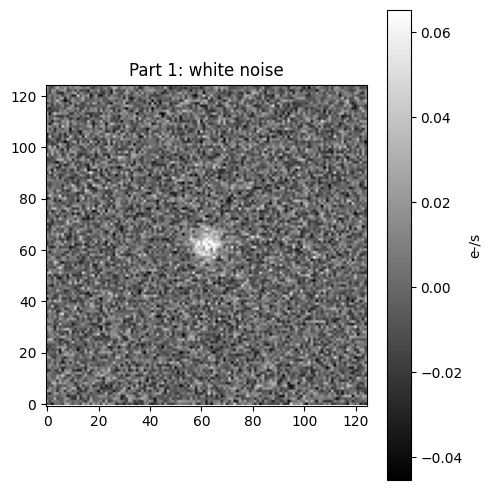

Peak SNR ~ 5.9


In [45]:
N = STAMP_SIZE
full_img = galsim.Image(N, N, scale=PIXEL_SCALE)
full_img.setZero()
for dx, dy, hlr, n, mag, lbl in truth_sources:
    flux = mag_to_flux(mag) * EXPTIME
    galsim.Convolve([_make_gal(lbl, hlr, n, flux), psf]).shift(dx=dx, dy=dy).drawImage(
        image=full_img, method='auto', add_to_image=True)

full_img.addNoise(galsim.GaussianNoise(rng=rng, sigma=READ_NOISE))
full_img /= EXPTIME

sci_arr = full_img.array
hdr = write_fits(sci_arr)

norm = ImageNormalize(sci_arr, interval=ZScaleInterval())
plt.figure(figsize=(5, 5))
plt.imshow(sci_arr, origin='lower', cmap='gray', norm=norm)
plt.colorbar(label='e-/s')
plt.title('Part 1: white noise')
plt.tight_layout(); plt.show()
print(f'Peak SNR ~ {(sci_arr.max() - SKY_RATE) / NOISE_SIGMA_RATE:.1f}')


### Single realisation: run slimfarmer

In [15]:
cat = slimfarmer.run_photometry(
    science_path=SCI_PATH, weight_path=WHT_PATH, eff_gain_path=EFF_GAIN_PATH,
    psf_path=PSF_PATH, band=BAND, zeropoint=ZP_RATE, output_path=OUT_PATH,
    #fixed_reff=truth_sources[0][2],model_priors = {'pos': 0.1*u.arcsec, 'reff': 0.01*u.arcsec, 'shape': 'none', 'fracDev': 'none'},
    ncpus=0, thresh=3.0, noshot=True)
print(f'{len(cat)} sources detected')
print(cat['id', 'ra', 'dec', f'{BAND}_flux', f'{BAND}_flux_err',
          f'{BAND}_flux_err_des', f'{BAND}_flux_err_tractor_origin', 'name', 'total_rchisq'])


Groups: 100%|██████████| 1/1 [00:02<00:00,  2.22s/it]


1 sources detected
 id        ra               dec        ...    name     total_rchisq  
          deg               deg        ...                           
--- ---------------- ----------------- ... --------- ----------------
  1 149.999994551038 2.000000867035735 ... ExpGalaxy 0.98961535446233


Let's calculate the SNR of the source. Note that Roman HLIS source sample cut at 18

In [16]:
print("SNR:", cat['F158_flux']/cat['F158_flux_err'])

SNR:     F158_flux     
------------------
18.893617200811143


In [17]:
from astropy.coordinates import SkyCoord
import astropy.units as u

wcs_obj = WCS(fits.getheader(SCI_PATH))
cat_c = SkyCoord(cat['ra'], cat['dec'], unit='deg')
truth_coords = []
for dx, dy, hlr, n, mag, lbl in truth_sources:
    px = (N - 1) / 2 + dx / PIXEL_SCALE
    py = (N - 1) / 2 + dy / PIXEL_SCALE
    ra, dec = wcs_obj.all_pix2world(px, py, 0)
    truth_coords.append((ra, dec, mag_to_flux(mag)))
tru_c = SkyCoord([t[0] for t in truth_coords], [t[1] for t in truth_coords], unit='deg')
idx, d2d, _ = cat_c.match_to_catalog_sky(tru_c)
sep_as = d2d.to(u.arcsec).value

print('Cross-match (sep < 1"):')
for i in range(len(cat)):
    if sep_as[i] < 1.0:
        obs = float(cat[f'{BAND}_flux'][i])
        tru = truth_coords[idx[i]][2]
        print(f'  id={int(cat["id"][i])}  sep={sep_as[i]:.3f}"  obs/true={obs/tru:.4f}  '
              f'flux_err={float(cat[f"{BAND}_flux_err"][i]):.4f}  '
              f'flux_err_des={float(cat[f"{BAND}_flux_err_des"][i]):.4f}  '
              f'model={cat["name"][i]}')


Cross-match (sep < 1"):
  id=1  sep=0.020"  obs/true=1.0801  flux_err=0.3607  flux_err_des=0.3273  model=ExpGalaxy


Ok the detection looks reasonable

### Monte Carlo (white noise)

In [18]:
def render_white(img_noiseless, rng_i):
    img_i = img_noiseless.copy()
    img_i.addNoise(galsim.GaussianNoise(rng=rng_i, sigma=READ_NOISE))
    img_i /= EXPTIME
    return img_i.array

mc1_ratios, mc1_flux, mc1_flux_err, mc1_flux_err_des = run_mc(render_white, N_REAL=50)


realisations:   0%|          | 0/50 [00:00<?, ?it/s]


Groups: 100%|██████████| 1/1 [00:02<00:00,  2.38s/it]

Groups: 100%|██████████| 1/1 [00:02<00:00,  2.12s/it]

Groups: 100%|██████████| 1/1 [00:02<00:00,  2.04s/it]

Groups: 100%|██████████| 1/1 [00:11<00:00, 11.55s/it]

Groups: 100%|██████████| 1/1 [00:07<00:00,  7.87s/it]

Groups: 100%|██████████| 1/1 [00:03<00:00,  3.68s/it]

Groups: 100%|██████████| 1/1 [00:01<00:00,  1.86s/it]

Groups: 100%|██████████| 1/1 [00:02<00:00,  2.20s/it]

Groups: 100%|██████████| 1/1 [00:02<00:00,  2.04s/it]

Groups: 100%|██████████| 1/1 [00:01<00:00,  1.85s/it]

Groups: 100%|██████████| 1/1 [00:01<00:00,  1.31s/it]

Groups: 100%|██████████| 1/1 [00:01<00:00,  1.42s/it]

Groups: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s]

Groups: 100%|██████████| 1/1 [00:00<00:00,  1.07it/s]

Groups: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s]

Groups: 100%|██████████| 1/1 [00:00<00:00,  1.31it/s]

Groups: 100%|██████████| 1/1 [00:01<00:00,  1.45s/it]

Groups: 100%|██████████| 1/1 [00:00<00:00,  1.65it/s]

Groups: 1

In [19]:
print(len(mc1_flux_err_des[0]))

50


ExpGalaxy  mag=21.0:
  sigma_MC       = 0.2586 e-/s
  flux_err       = 0.2780 e-/s  (ratio 1.075)
  flux_err_des   = 0.2646 e-/s  (ratio 1.023)


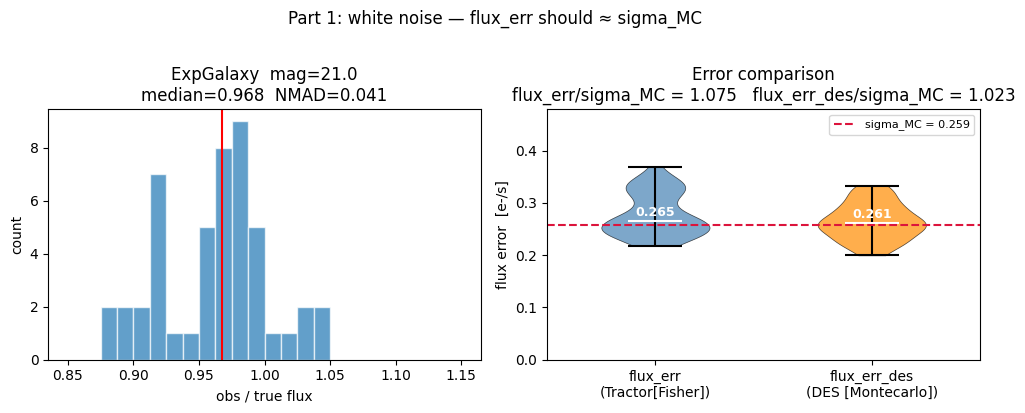

In [23]:
plot_mc_results(mc1_ratios, mc1_flux, mc1_flux_err, mc1_flux_err_des,
                title='Part 1: white noise — flux_err should ≈ sigma_MC')


I think this looks reasonable... Slimfarmer is great :-)

---
# Part 2: Correlated noise from imcom data

Noise is drawn from the correlated noise power spectrum of a imcom image.  
The weight map still assumes white noise at the same variance, so slimfarmer's Fisher error underestimates the true scatter (`sigma_MC > flux_err`).


### Load noise image from CPR file

I want to study the impact of total noise (poisson+background) correlation, so I use the layer that have poisson+background noise.

Noise image shape: (2108, 2108)


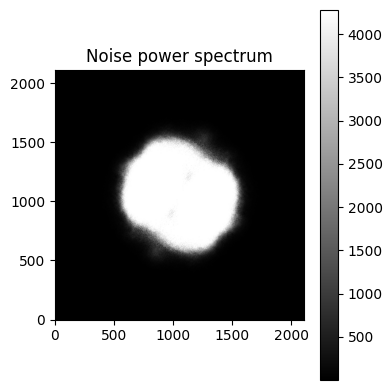

In [35]:
CPR_PATH = 'im3x2-H1_00_00.cpr.fits.gz'
from pyimcom.compress.compressutils import ReadFile
cpr   = ReadFile(CPR_PATH)
noise = cpr[0].data[0][24]
print(f'Noise image shape: {noise.shape}')

L  = len(noise)
ps = np.empty((L, L), dtype=np.float64)
rps = np.square(np.abs(np.fft.fftshift(np.fft.rfft2(noise), 0)))
ps[:, L // 2:] = rps[:, :-1]
ps[1:, :L // 2] = rps[L - 1:0:-1, L // 2:0:-1]
ps[0,  :L // 2] = rps[0,  L // 2:0:-1]

norm = ImageNormalize(ps, interval=ZScaleInterval())
plt.figure(figsize=(4, 4))
plt.imshow(ps, origin='lower', cmap='gray', norm=norm)
plt.title('Noise power spectrum'); plt.colorbar(); plt.tight_layout(); plt.show()


### Render science image (correlated noise)

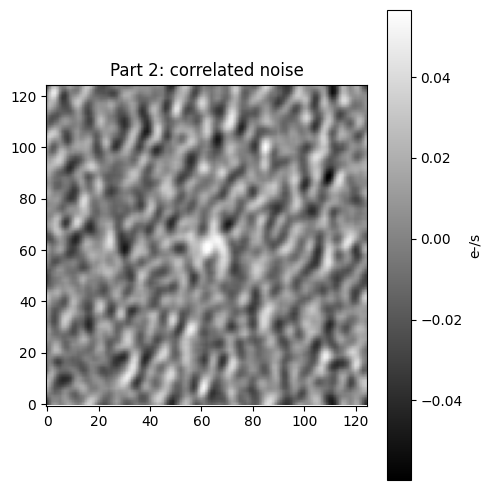

In [46]:
N = STAMP_SIZE
full_img2 = galsim.Image(N, N, scale=PIXEL_SCALE)
full_img2.setZero()
for dx, dy, hlr, n, mag, lbl in truth_sources:
    flux = mag_to_flux(mag) * EXPTIME
    galsim.Convolve([_make_gal(lbl, hlr, n, flux), psf]).shift(dx=dx, dy=dy).drawImage(
        image=full_img2, method='auto', add_to_image=True)

noise_galsim = galsim.Image(noise.astype(np.float64), scale=PIXEL_SCALE)
cn = galsim.CorrelatedNoise(noise_galsim, rng).withVariance(READ_NOISE**2)
full_img2.addNoise(cn)
full_img2 /= EXPTIME

sci_arr2 = full_img2.array
hdr2 = write_fits(sci_arr2)

norm = ImageNormalize(sci_arr2, interval=ZScaleInterval())
plt.figure(figsize=(5, 5))
plt.imshow(sci_arr2, origin='lower', cmap='gray', norm=norm)
plt.colorbar(label='e-/s')
plt.title('Part 2: correlated noise')
plt.tight_layout(); plt.show()


### Single realisation: run slimfarmer

In [48]:
cat2 = slimfarmer.run_photometry(
    science_path=SCI_PATH, weight_path=WHT_PATH, eff_gain_path=EFF_GAIN_PATH,
    psf_path=PSF_PATH, band=BAND, zeropoint=ZP_RATE, output_path=OUT_PATH,
    ncpus=0, thresh=10.0)
print(f'{len(cat2)} sources detected')
print(cat2['id', f'{BAND}_flux', f'{BAND}_flux_err', f'{BAND}_flux_err_des',
           f'{BAND}_flux_err_tractor_origin', 'name', 'total_rchisq'])


Groups: 100%|██████████| 1/1 [00:00<00:00,  1.00it/s]

1 sources detected
 id     F158_flux       F158_flux_err    ...    name       total_rchisq   
--- ----------------- ------------------ ... --------- -------------------
  1 7.875655660870902 0.4917515404101591 ... ExpGalaxy 0.32428931063906286


In [49]:
print("SNR:", cat2['F158_flux']/cat2['F158_flux_err'])

SNR:     F158_flux     
------------------
16.015518028274993


### Monte Carlo (correlated noise)

In [50]:
noise_galsim_template = galsim.Image(noise.astype(np.float64), scale=PIXEL_SCALE)
def render_correlated(img_noiseless, rng_i):
    img_i = img_noiseless.copy()
    cn_i  = galsim.CorrelatedNoise(noise_galsim_template, rng_i).withVariance(READ_NOISE**2)
    img_i.addNoise(cn_i)
    img_i /= EXPTIME
    return img_i.array

mc2_ratios, mc2_flux, mc2_flux_err, mc2_flux_err_des = run_mc(render_correlated, N_REAL=50)


realisations:   0%|          | 0/50 [00:00<?, ?it/s]


Groups: 100%|██████████| 2/2 [00:05<00:00,  2.86s/it]

Groups: 100%|██████████| 1/1 [00:06<00:00,  6.74s/it]

Groups: 100%|██████████| 3/3 [00:27<00:00,  9.17s/it]

Groups: 100%|██████████| 1/1 [00:10<00:00, 10.79s/it]

Groups: 100%|██████████| 1/1 [00:01<00:00,  1.47s/it]

Groups: 100%|██████████| 1/1 [00:01<00:00,  1.20s/it]

Groups: 100%|██████████| 2/2 [00:03<00:00,  1.58s/it]

Groups: 100%|██████████| 3/3 [00:15<00:00,  5.09s/it]

Groups: 100%|██████████| 2/2 [00:11<00:00,  5.56s/it]

Groups: 100%|██████████| 1/1 [00:02<00:00,  2.83s/it]

Groups: 100%|██████████| 5/5 [00:13<00:00,  2.67s/it]

Groups: 100%|██████████| 4/4 [00:14<00:00,  3.65s/it]

Groups: 100%|██████████| 4/4 [00:07<00:00,  1.85s/it]

Groups: 100%|██████████| 2/2 [00:12<00:00,  6.06s/it]

Groups: 100%|██████████| 3/3 [00:05<00:00,  1.91s/it]

Groups: 100%|██████████| 4/4 [00:23<00:00,  5.83s/it]

Groups: 100%|██████████| 2/2 [00:05<00:00,  2.71s/it]

Groups: 100%|██████████| 2/2 [00:11<00:00,  5.82s/it]

Groups: 1

In [51]:
len(mc2_flux[0])

50

ExpGalaxy  mag=21.0:
  sigma_MC       = 0.9481 e-/s
  flux_err       = 0.2187 e-/s  (ratio 0.231)
  flux_err_des   = 0.1666 e-/s  (ratio 0.176)


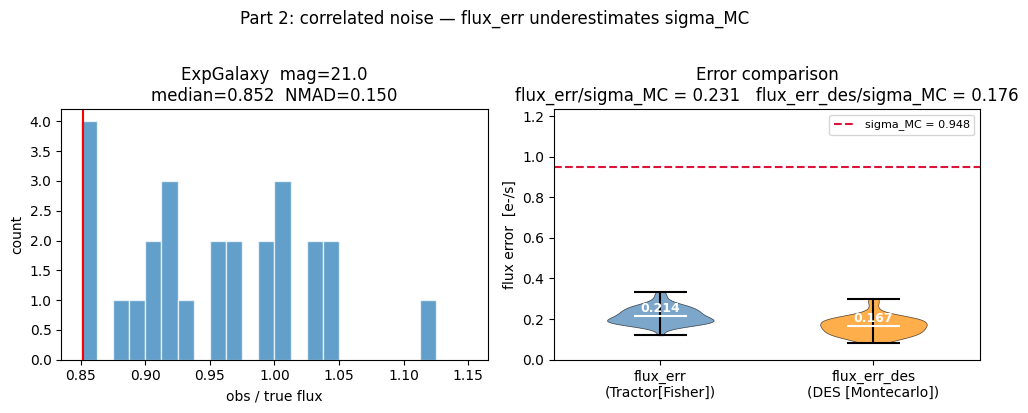

In [52]:
plot_mc_results(mc2_ratios, mc2_flux, mc2_flux_err, mc2_flux_err_des,
                title='Part 2: correlated noise — flux_err underestimates sigma_MC')


## Summary: white vs correlated noise

In [53]:
for ti, (dx, dy, hlr, n, mag, lbl) in enumerate(truth_sources):
    f1 = np.array(mc1_flux[ti]); e1 = np.array(mc1_flux_err[ti]); e1d = np.array(mc1_flux_err_des[ti])
    f2 = np.array(mc2_flux[ti]); e2 = np.array(mc2_flux_err[ti]); e2d = np.array(mc2_flux_err_des[ti])
    if len(f1) < 3 or len(f2) < 3:
        continue

    N1, N2 = len(f1), len(f2)

    s1 = stats.median_abs_deviation(f1, scale='normal')
    s2 = stats.median_abs_deviation(f2, scale='normal')

    # Asymptotic SE of the MAD-based sigma estimator (normal assumption)
    se_s1 = s1 * np.sqrt(np.pi / 2) / np.sqrt(N1)
    se_s2 = s2 * np.sqrt(np.pi / 2) / np.sqrt(N2)

    # SE of mean flux_err
    mean_e1d, mean_e2d = np.mean(e1d), np.mean(e2d)
    se_e1d = np.std(e1d, ddof=1) / np.sqrt(N1)
    se_e2d = np.std(e2d, ddof=1) / np.sqrt(N2)

    # Ratio and its error via propagation: SE(R)/R = sqrt((SE_s/s)^2 + (SE_e/e)^2)
    r1 = s1 / mean_e1d
    r2 = s2 / mean_e2d
    se_r1 = r1 * np.sqrt((se_s1 / s1)**2 + (se_e1d / mean_e1d)**2)
    se_r2 = r2 * np.sqrt((se_s2 / s2)**2 + (se_e2d / mean_e2d)**2)

    print(f'{lbl}  mag={mag:.1f}')
    print(f'  White noise  sigma_MC/flux_err = {r1:.3f} ± {se_r1:.3f}')
    print(f'  Corr  noise  sigma_MC/flux_err = {r2:.3f} ± {se_r2:.3f}')
    print()

ExpGalaxy  mag=21.0
  White noise  sigma_MC/flux_err = 0.977 ± 0.174
  Corr  noise  sigma_MC/flux_err = 5.690 ± 1.032



# Summary

In these tests, I assume that slimfarmer has perfect knowledge of the galaxy size in order to isolate the flux uncertainty calculation from additional size-related errors. I also neglect Poisson shot noise in both the slimfarmer calculation and the simulations to avoid unnecessary complications.

Our main findings are:

1. In the absence of noise correlations, the flux uncertainties estimated by slimfarmer are consistent with expectations from Monte Carlo simulations.
2. When realistic noise correlations from the Dec25 simulations are included, slimfarmer's naive uncertainty estimate underestimates the true flux uncertainty by a factor of about 6.

Together, these results demonstrate the importance of developing methods that correctly account for noise correlations in flux uncertainty estimation.